# Clientes, productos y satisfacción

**Pregunta de negocio:** ¿de dónde vienen los clientes (geografía), qué categorías de producto generan más revenue, y cómo se relaciona el tiempo de entrega con la satisfacción del cliente (`review_score`)?

**Fuente de datos:** `dim_customer`, `dim_product`, `fct_orders`, más `stg_order_items` y `stg_order_reviews` (staging -- no son mart, pero necesarios para el detalle producto/review a nivel de línea de pedido).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA_DIR = Path("../data/raw")

orders = pd.read_parquet(DATA_DIR / "fct_orders.parquet")
customers = pd.read_parquet(DATA_DIR / "dim_customer.parquet")
products = pd.read_parquet(DATA_DIR / "dim_product.parquet")
order_items = pd.read_parquet(DATA_DIR / "stg_order_items.parquet")
reviews = pd.read_parquet(DATA_DIR / "stg_order_reviews.parquet")
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
print(orders.shape, customers.shape, products.shape, order_items.shape, reviews.shape)

(99491, 15) (99441, 5) (32951, 10) (112748, 8) (98410, 8)


## Revenue por estado del cliente (top 10)

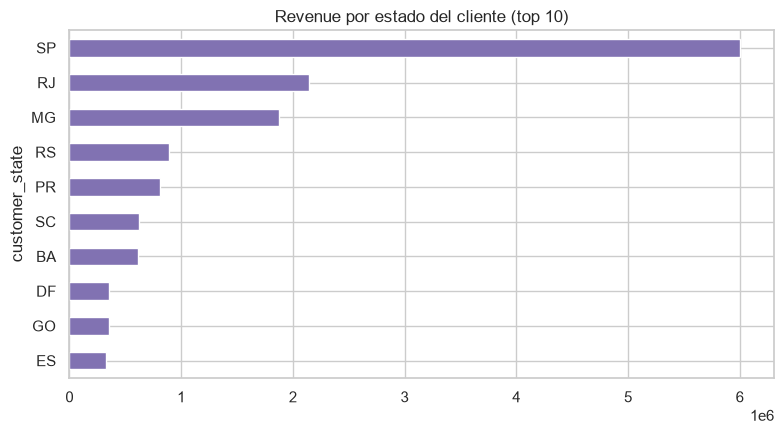

In [2]:
orders_customers = orders.merge(customers, on="customer_id", how="left")
by_state = orders_customers.groupby("customer_state").agg(
    revenue=("payment_value", "sum"),
    n_orders=("order_id", "nunique"),
).sort_values("revenue", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
by_state["revenue"].sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Revenue por estado del cliente (top 10)")
fig.tight_layout()

## Revenue por categoría de producto (top 15)

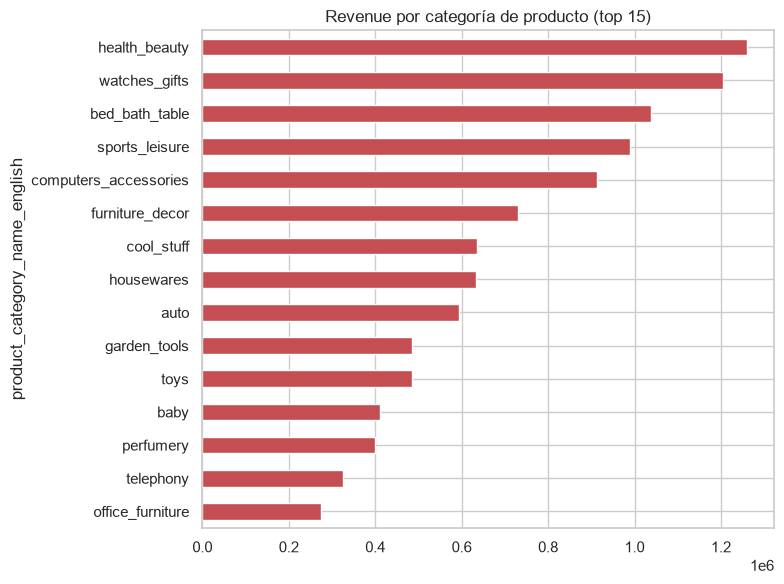

In [3]:
items_products = order_items.merge(products, on="product_id", how="left")
by_category = (
    items_products.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
by_category.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Revenue por categoría de producto (top 15)")
fig.tight_layout()

## Distribución de review_score

Promedio: 4.09


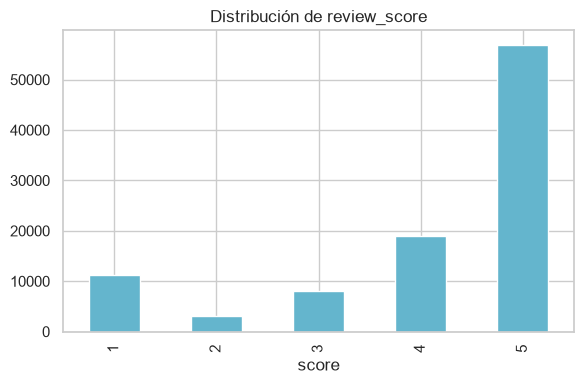

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
reviews["review_score"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#64B5CD")
ax.set_title("Distribución de review_score")
ax.set_xlabel("score")
fig.tight_layout()
print("Promedio:", round(reviews["review_score"].mean(), 2))

## Tiempo de entrega vs. satisfacción

¿Los pedidos que llegan más tarde de lo estimado reciben peor score?

delay_bucket
muy_temprano      4.30
a_tiempo          4.15
justo_a_tiempo    4.04
tarde_1_7d        2.72
tarde_8d_mas      1.70
Name: review_score, dtype: float64

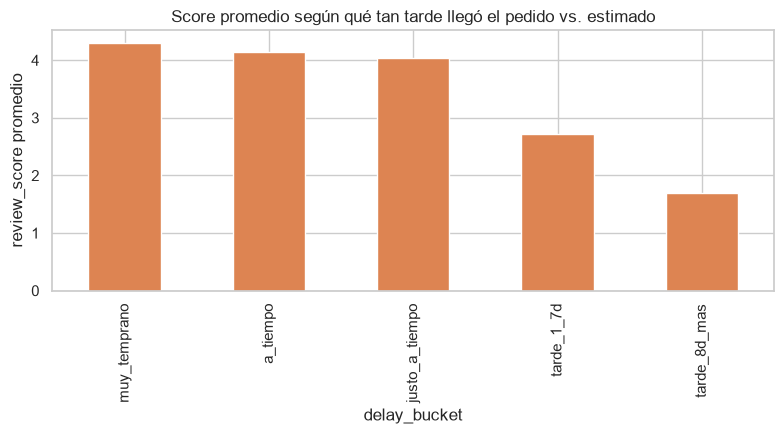

In [5]:
delivered = orders[
    orders["is_delivered"] == True
].copy()
delivered["order_delivered_customer_date"] = pd.to_datetime(delivered["order_delivered_customer_date"])
delivered["order_estimated_delivery_date"] = pd.to_datetime(delivered["order_estimated_delivery_date"])
delivered["delay_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]
).dt.days

delivered_reviews = delivered.merge(
    reviews[["order_id", "review_score"]], on="order_id", how="inner"
)

def delay_bucket(days):
    if pd.isna(days):
        return "sin_dato"
    if days <= -3:
        return "muy_temprano"
    if days < 0:
        return "a_tiempo"
    if days == 0:
        return "justo_a_tiempo"
    if days <= 7:
        return "tarde_1_7d"
    return "tarde_8d_mas"

delivered_reviews["delay_bucket"] = delivered_reviews["delay_days"].apply(delay_bucket)
order = ["muy_temprano", "a_tiempo", "justo_a_tiempo", "tarde_1_7d", "tarde_8d_mas"]
avg_score = delivered_reviews.groupby("delay_bucket")["review_score"].mean().reindex(order)

fig, ax = plt.subplots(figsize=(8, 4.5))
avg_score.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_ylabel("review_score promedio")
ax.set_title("Score promedio según qué tan tarde llegó el pedido vs. estimado")
fig.tight_layout()
avg_score.round(2)

## Conclusiones

- La concentración de revenue por estado y por categoría suele seguir una distribución muy desigual (pocos estados/categorías explican la mayoría del revenue) -- útil para priorizar dónde enfocar marketing o inventario.
- Si el score promedio cae claramente en los buckets de "tarde", hay una relación clara entre cumplir la fecha estimada de entrega y la satisfacción -- una palanca operativa, no solo de marketing, para mejorar retención.